In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving EasyVisa.csv to EasyVisa (2).csv


In [5]:
df = pd.read_csv("/content/EasyVisa.csv")
print("Shape of dataset:", df.shape)
print("\nColumns in dataset:\n", df.columns)
print("\nData types:\n", df.dtypes)

Shape of dataset: (25480, 12)

Columns in dataset:
 Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

Data types:
 case_id                   object
continent                 object
education_of_employee     object
has_job_experience        object
requires_job_training     object
no_of_employees            int64
yr_of_estab                int64
region_of_employment      object
prevailing_wage          float64
unit_of_wage              object
full_time_position        object
case_status               object
dtype: object


In [6]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [7]:
print("Missing Values:\n", df.isnull().sum())
print("\nUnique Values per Column:\n", df.nunique())

Missing Values:
 case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

Unique Values per Column:
 case_id                  25480
continent                    6
education_of_employee        4
has_job_experience           2
requires_job_training        2
no_of_employees           7105
yr_of_estab                199
region_of_employment         5
prevailing_wage          25454
unit_of_wage                 4
full_time_position           2
case_status                  2
dtype: int64


/tmp/ipython-input-2128309421.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=case_counts.index, y=case_counts.values, palette="Set2")


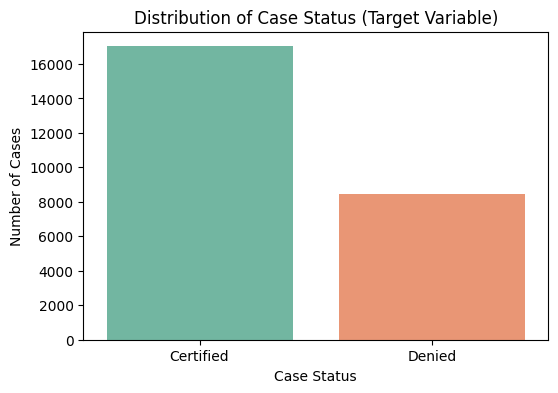

Percentage Distribution:
 case_status
Certified    66.789639
Denied       33.210361
Name: proportion, dtype: float64


In [8]:
case_counts = df['case_status'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=case_counts.index, y=case_counts.values, palette="Set2")
plt.title("Distribution of Case Status (Target Variable)")
plt.ylabel("Number of Cases")
plt.xlabel("Case Status")
plt.show()

case_percent = df['case_status'].value_counts(normalize=True) * 100
print("Percentage Distribution:\n", case_percent)

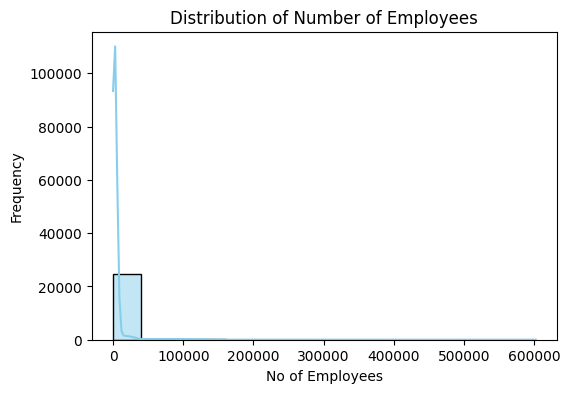

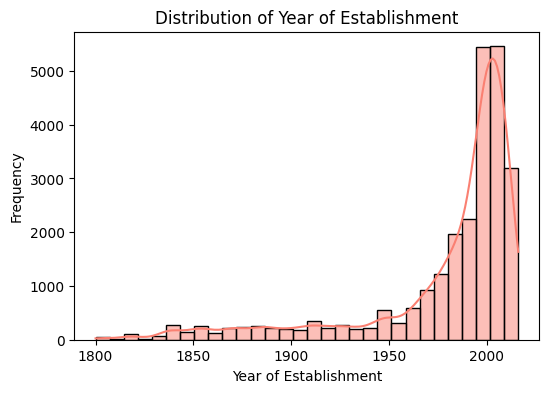

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['no_of_employees'], bins=15, kde=True, color="skyblue")
plt.title("Distribution of Number of Employees")
plt.xlabel("No of Employees")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['yr_of_estab'], bins=30, kde=True, color="salmon")
plt.title("Distribution of Year of Establishment")
plt.xlabel("Year of Establishment")
plt.ylabel("Frequency")
plt.show()

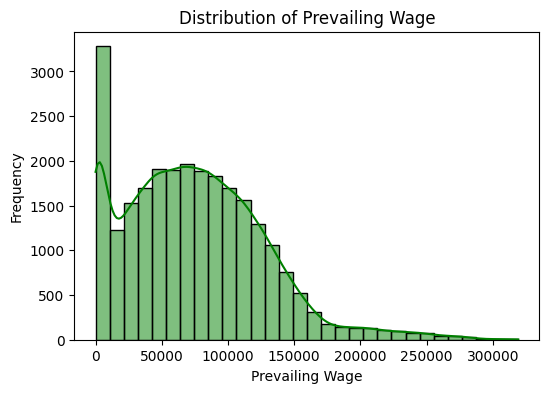

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['prevailing_wage'], bins=30, kde=True, color="green")
plt.title("Distribution of Prevailing Wage")
plt.xlabel("Prevailing Wage")
plt.ylabel("Frequency")
plt.show()

In [11]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
categorical_cols

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [12]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("-"*50)


Column: case_id
case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------

Column: continent
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------

Column: education_of_employee
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------

Column: has_job_experience
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------

Column: requires_job_training
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
-------------

In [13]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(normalize=True) * 100)
    print("-"*50)


Column: case_id
case_id
EZYV25480    0.003925
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
               ...   
EZYV13       0.003925
EZYV12       0.003925
EZYV11       0.003925
EZYV10       0.003925
EZYV09       0.003925
Name: proportion, Length: 25480, dtype: float64
--------------------------------------------------

Column: continent
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
--------------------------------------------------

Column: education_of_employee
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
--------------------------------------------------

Column: has_job_experience
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
------------

/tmp/ipython-input-3268188463.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="Set2")
/tmp/ipython-input-3268188463.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="Set2")
/tmp/ipython-input-3268188463.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="Set2")
/tmp/ipython-input-3268188463.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` vari

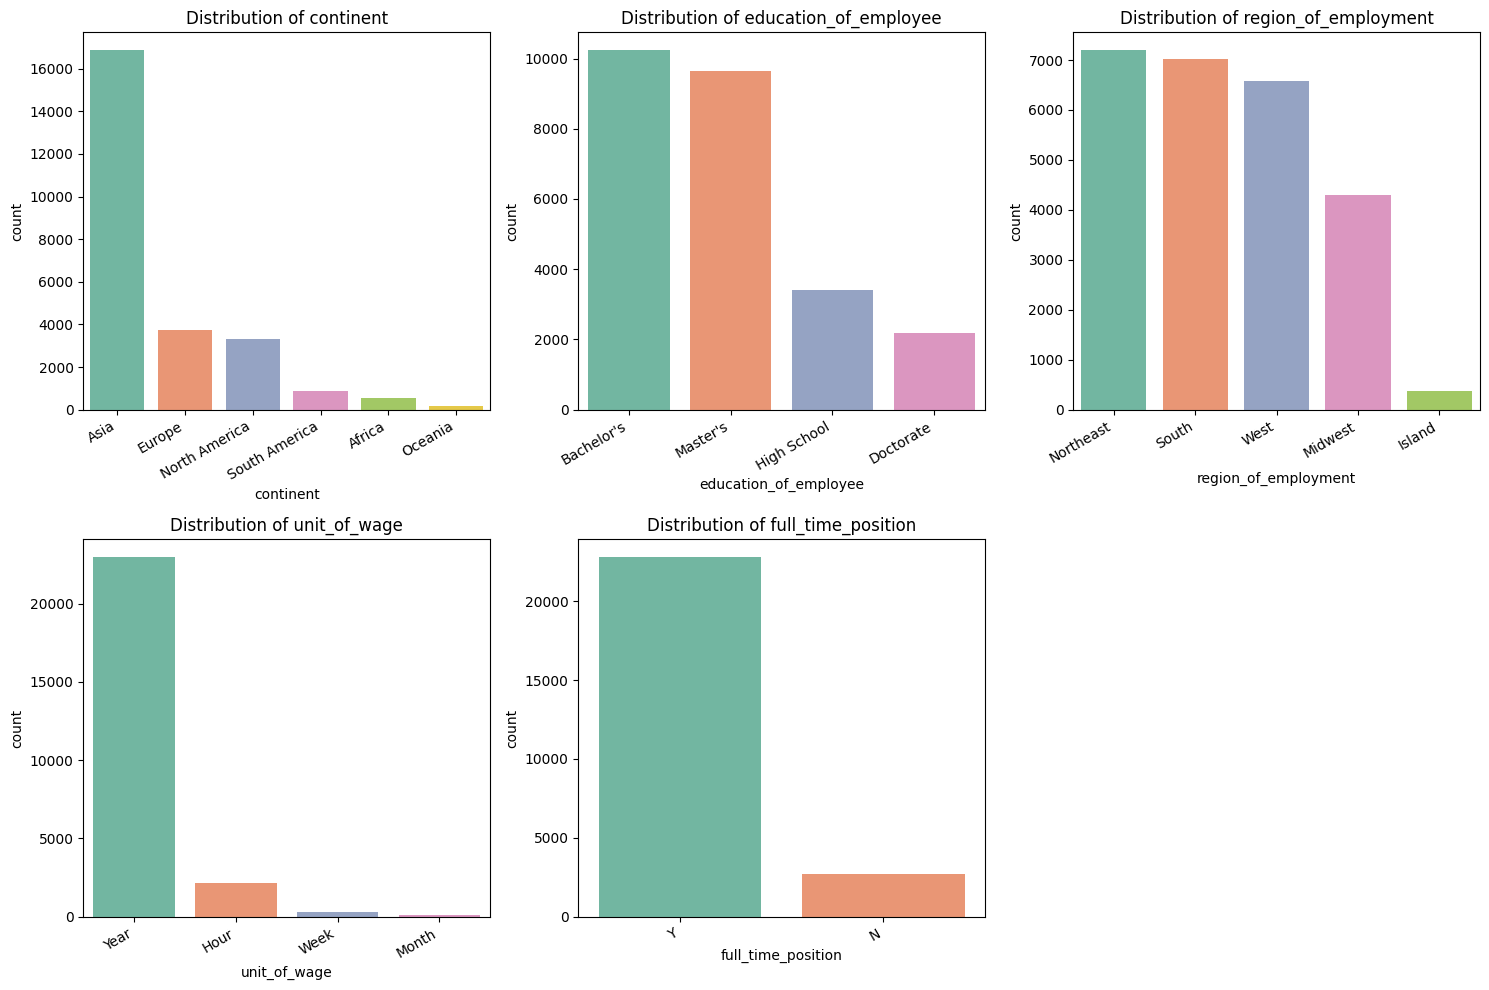

In [14]:
cat_cols_to_plot = ["continent", "education_of_employee", "region_of_employment",
                    "unit_of_wage", "full_time_position"]

plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_cols_to_plot, 1):
    plt.subplot(2, 3, i)
    order = df[col].value_counts().index  # sort by frequency
    sns.countplot(data=df, x=col, order=order, palette="Set2")
    plt.title(f"Distribution of {col}", fontsize=12)
    plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

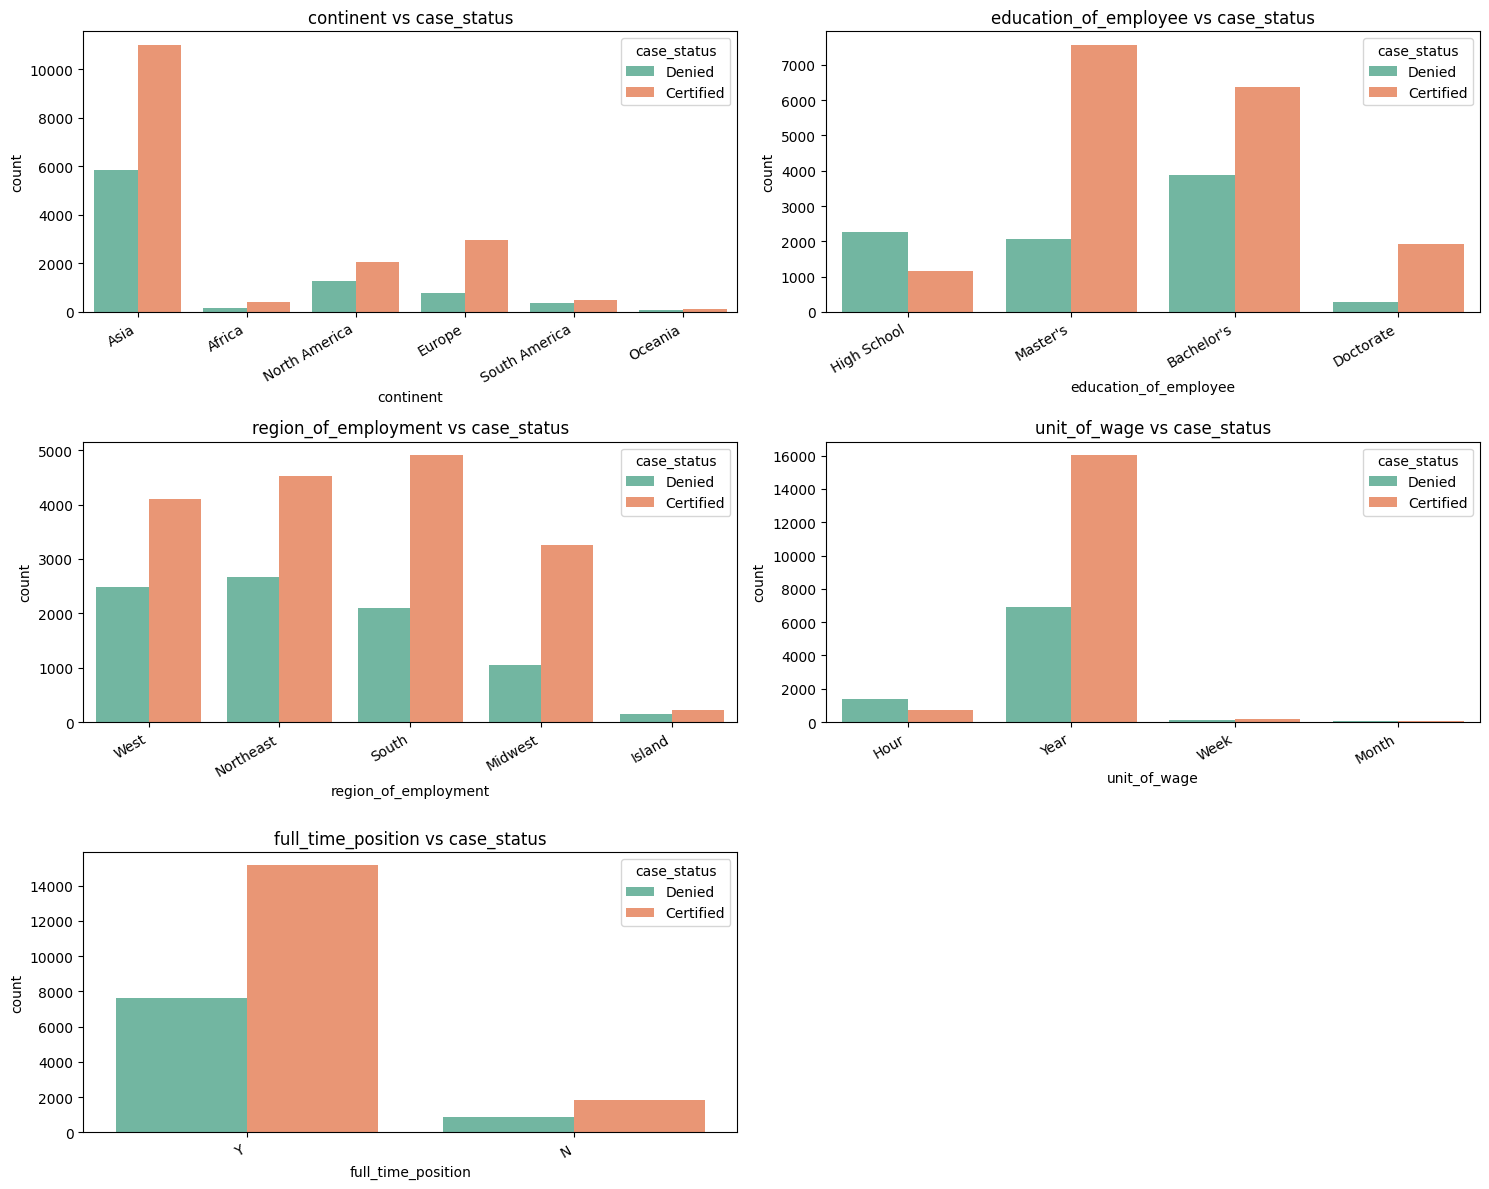

In [15]:
cat_cols = ["continent", "education_of_employee", "region_of_employment",
            "unit_of_wage", "full_time_position"]

plt.figure(figsize=(15, 12))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=df, x=col, hue="case_status", palette="Set2")
    plt.title(f"{col} vs case_status", fontsize=12)
    plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

/tmp/ipython-input-790233556.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="case_status", y=col, palette="Set3")


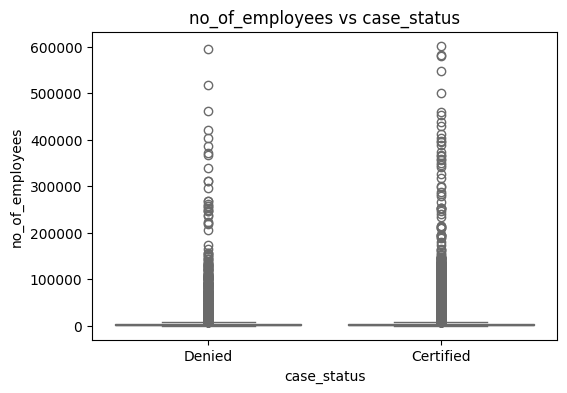

/tmp/ipython-input-790233556.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="case_status", y=col, palette="Set3")


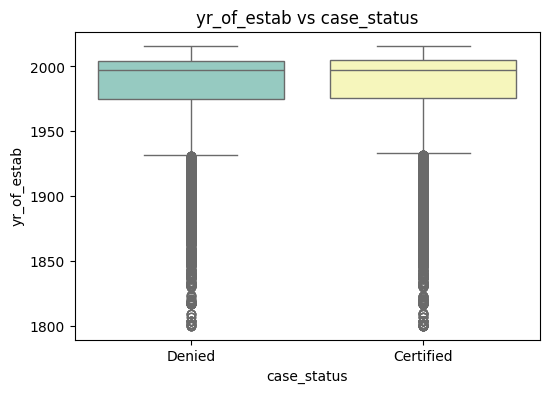

/tmp/ipython-input-790233556.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="case_status", y=col, palette="Set3")


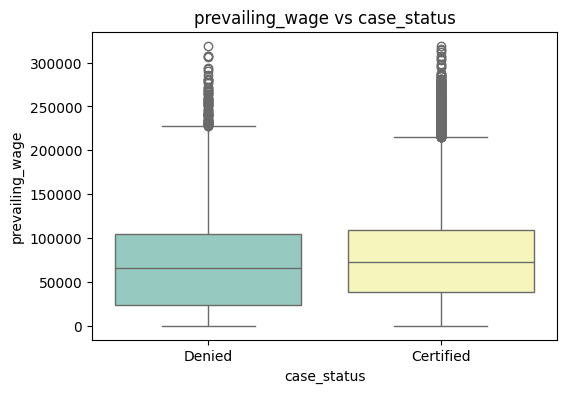

In [16]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

drop_cols = ['year']
num_cols = [col for col in num_cols if col not in drop_cols and col in df.columns]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="case_status", y=col, palette="Set3")
    plt.title(f"{col} vs case_status")
    plt.show()

In [17]:
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


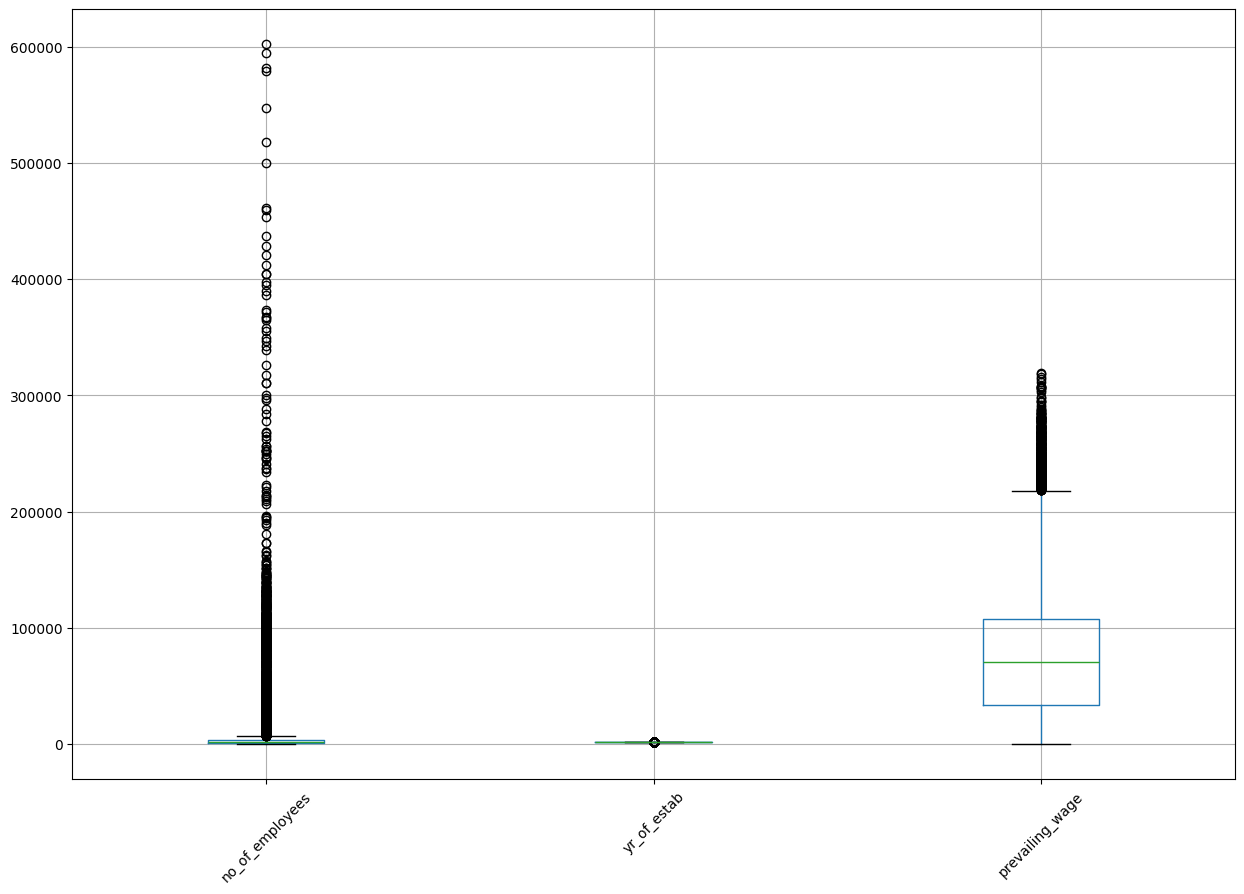

In [18]:
import matplotlib.pyplot as plt

# only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15,10))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.show()

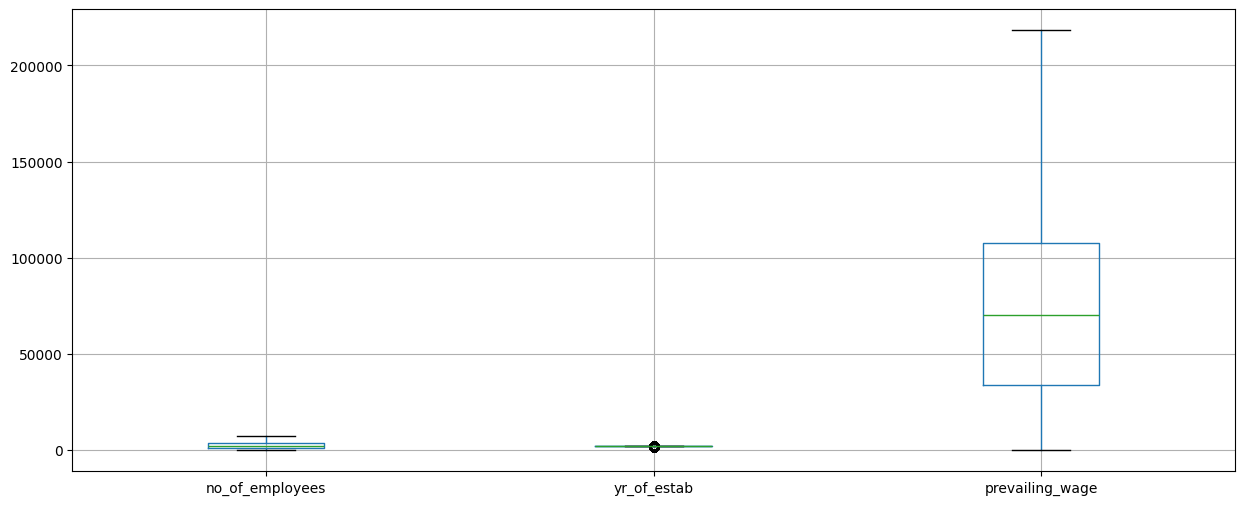

In [19]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower,
              np.where(df[col] > upper, upper, df[col]))
    return df

for col in ["no_of_employees", "prevailing_wage"]:
    df = cap_outliers(df, col)

plt.figure(figsize=(15,6))
df[["no_of_employees","yr_of_estab","prevailing_wage"]].boxplot()
plt.show()

In [20]:
df.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [21]:
categorical_cols = ["continent", "education_of_employee", "has_job_experience",
                    "requires_job_training", "region_of_employment",
                    "unit_of_wage", "full_time_position"]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop("case_status", axis=1)
y = df_encoded["case_status"]

df_encoded.head()

,case_id,no_of_employees,yr_of_estab,prevailing_wage,case_status,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,...,has_job_experience_Y,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y
0,EZYV01,7227.0,2007,592.2029,Denied,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,EZYV02,2412.0,2002,83425.6500,Certified,True,False,False,False,False,...,True,False,False,True,False,False,False,False,True,True
2,EZYV03,7227.0,2008,122996.8600,Denied,True,False,False,False,False,...,False,True,False,False,False,True,False,False,True,True
3,EZYV04,98.0,1897,83434.0300,Denied,True,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
4,EZYV05,1082.0,2005,149907.3900,Certified,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,True


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

df_model = df_encoded.drop("case_id", axis=1)

df_model["case_status"] = df_model["case_status"].map({"Certified": 1, "Denied": 0})


X = df_model.drop("case_status", axis=1)
y = df_model["case_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (20384, 21)
Test shape: (5096, 21)


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_pred_log_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

acc_log = accuracy_score(y_test, y_pred_log)
roc_log = roc_auc_score(y_test, y_pred_log_prob)

print("Logistic Regression Accuracy:", acc_log)
print("Logistic Regression ROC-AUC:", roc_log)


Logistic Regression Accuracy: 0.728414442700157
Logistic Regression ROC-AUC: 0.7571869973581352


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_proba_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree ROC-AUC:", dt_roc_auc)


Decision Tree Accuracy: 0.6569858712715856
Decision Tree ROC-AUC: 0.6160225905831826


Random Forest Performance (Original Data):
Accuracy: 0.7199764521193093
ROC-AUC: 0.7467789250860482

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.49      0.54      1692
           1       0.77      0.84      0.80      3404

    accuracy                           0.72      5096
   macro avg       0.68      0.66      0.67      5096
weighted avg       0.71      0.72      0.71      5096



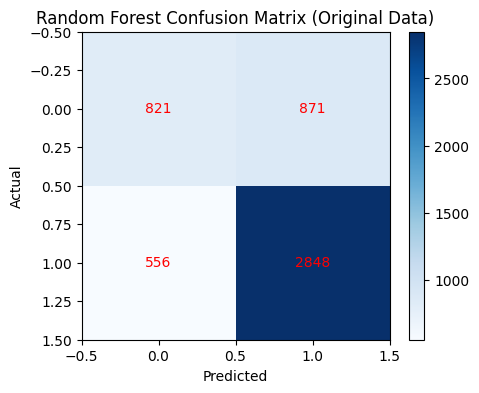

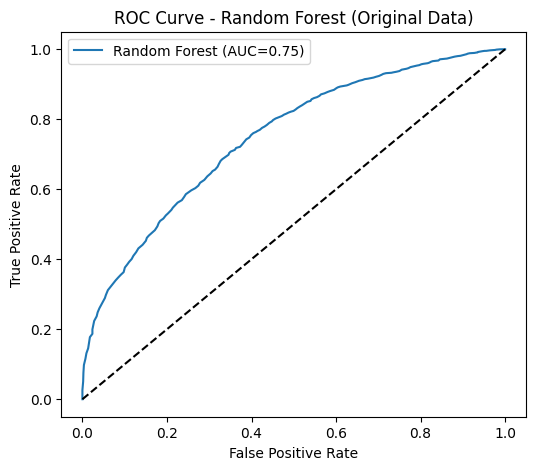

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

rf = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=None)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance (Original Data):")
print("Accuracy:", rf_acc)
print("ROC-AUC:", rf_auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Random Forest Confusion Matrix (Original Data)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC={rf_auc:.2f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (Original Data)")
plt.legend()
plt.show()

In [29]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)[:, 1]

ada_acc = accuracy_score(y_test, y_pred_ada)
ada_roc = roc_auc_score(y_test, y_prob_ada)

print("AdaBoost Accuracy:", ada_acc)
print("AdaBoost ROC-AUC:", ada_roc)


AdaBoost Accuracy: 0.7321428571428571
AdaBoost ROC-AUC: 0.7554605657924345


In [30]:
from sklearn.svm import SVC

svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:, 1]

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_roc = roc_auc_score(y_test, y_prob_svm)

print("SVM Accuracy:", svm_acc)
print("SVM ROC-AUC:", svm_roc)

SVM Accuracy: 0.6679748822605965
SVM ROC-AUC: 0.5530607503896126


In [34]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, roc_auc_score

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

models_resampled = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

results_resampled = {}

for name, model in models_resampled.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    results_resampled[name] = {"Accuracy": acc, "ROC-AUC": auc}
    print(f"{name} (Oversampled) → Accuracy: {acc:.4f}, ROC-AUC: {auc:.4f}")

results_resampled


Before SMOTE: case_status
1    13614
0     6770
Name: count, dtype: int64
After SMOTE: case_status
1    13614
0    13614
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression (Oversampled) → Accuracy: 0.7288, ROC-AUC: 0.7416
Decision Tree (Oversampled) → Accuracy: 0.6442, ROC-AUC: 0.6045
Random Forest (Oversampled) → Accuracy: 0.7182, ROC-AUC: 0.7429
AdaBoost (Oversampled) → Accuracy: 0.7290, ROC-AUC: 0.7422


{'Logistic Regression': {'Accuracy': 0.728806907378336,
  'ROC-AUC': np.float64(0.7415754098224033)},
 'Decision Tree': {'Accuracy': 0.6442307692307693,
  'ROC-AUC': np.float64(0.6045429101627067)},
 'Random Forest': {'Accuracy': 0.7182103610675039,
  'ROC-AUC': np.float64(0.7429242957110672)},
 'AdaBoost': {'Accuracy': 0.7290031397174255,
  'ROC-AUC': np.float64(0.7422494187064029)}}

In [35]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Original Training Set Shape:", y_train.value_counts().to_dict())
print("Undersampled Training Set Shape:", y_train_under.value_counts().to_dict())

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42)
}

results_under = {}

for name, model in models.items():
    model.fit(X_train_under, y_train_under)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results_under[name] = {"Accuracy": acc, "ROC-AUC": roc}

import pandas as pd
results_under_df = pd.DataFrame(results_under).T
print("\nModel Performance on Undersampled Data:")
print(results_under_df)

Original Training Set Shape: {1: 13614, 0: 6770}
Undersampled Training Set Shape: {0: 6770, 1: 6770}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model Performance on Undersampled Data:
                     Accuracy   ROC-AUC
Logistic Regression  0.693289  0.754577
Decision Tree        0.621468  0.620796
Random Forest        0.677590  0.745683
AdaBoost             0.691915  0.755273
Gradient Boost       0.700746  0.767801


In [37]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import numpy as np

# Logistic Regression

log_reg = LogisticRegression(max_iter=1000, solver='liblinear')
param_grid_lr = {
    'C': np.logspace(-3, 3, 7),
    'penalty': ['l1', 'l2']
}
random_search_lr = RandomizedSearchCV(
    log_reg,
    param_distributions=param_grid_lr,
    n_iter=10,  # keep small
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)
random_search_lr.fit(X_train, y_train)


# Random Forest

rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_grid_rf,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)
random_search_rf.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}
random_search_gb = RandomizedSearchCV(
    gb,
    param_distributions=param_grid_gb,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)
random_search_gb.fit(X_train, y_train)

print("Best Logistic Regression:", random_search_lr.best_score_, random_search_lr.best_params_)
print("Best Random Forest:", random_search_rf.best_score_, random_search_rf.best_params_)
print("Best Gradient Boosting:", random_search_gb.best_score_, random_search_gb.best_params_)


Best Logistic Regression: 0.773101305600057 {'penalty': 'l1', 'C': np.float64(10.0)}
Best Random Forest: 0.7839375246788011 {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}
Best Gradient Boosting: 0.7823071091076326 {'subsample': 1.0, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}


In [38]:
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

best_log_reg = LogisticRegression(
    penalty='l1',
    C=10.0,
    solver='liblinear',
    random_state=42
)

best_rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=2,
    min_samples_leaf=4,
    max_depth=10,
    random_state=42
)

best_gb = GradientBoostingClassifier(
    subsample=1.0,
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

best_log_reg.fit(X_train, y_train)
best_rf.fit(X_train, y_train)
best_gb.fit(X_train, y_train)

models = {
    "Logistic Regression": best_log_reg,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    results.append({"Model": name, "Accuracy": acc, "ROC-AUC": roc})

comparison_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print(comparison_df)

                 Model  Accuracy   ROC-AUC
1        Random Forest  0.738226  0.770879
2    Gradient Boosting  0.743524  0.767750
0  Logistic Regression  0.728414  0.757156
